# Customer Conversion Optimization & Prediction  
## 3. Modeling and Evaluation

This notebook builds and evaluates a machine learning model to predict customer response.

### Objectives
* ⁠Split the data into training and testing sets
* ⁠Train a classification model
* ⁠Evaluate model performance
*  ⁠Visualize ROC curve and confusion matrix
*  ⁠Interpret feature importance
*  ⁠Perform decile analysis for business relevance

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

### Load Processed Data

In [2]:
# Load processed dataset created in Notebook 2
df = pd.read_csv("../outputs/processed_data.csv")

# Check shape
print("Processed dataset shape:", df.shape)

# Preview data
df.head()

Processed dataset shape: (45211, 56)


,age,balance,day,duration,campaign,pdays,previous,target,balance_log,was_contacted_before,...,poutcome_success,poutcome_unknown,campaign_group_2-3,campaign_group_4-5,campaign_group_6+,age_group_26-35,age_group_36-45,age_group_46-55,age_group_56-65,age_group_65+
0,58,2143,5,261,1,-1,0,0,7.670429,0,...,False,True,False,False,False,False,False,False,True,False
1,44,29,5,151,1,-1,0,0,3.401197,0,...,False,True,False,False,False,False,True,False,False,False
2,33,2,5,76,1,-1,0,0,1.098612,0,...,False,True,False,False,False,True,False,False,False,False
3,47,1506,5,92,1,-1,0,0,7.317876,0,...,False,True,False,False,False,False,False,True,False,False
4,33,1,5,198,1,-1,0,0,0.693147,0,...,False,True,False,False,False,True,False,False,False,False


### Define Features and Target

In [3]:
# Separate predictors and target
X = df.drop("target", axis=1)
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (45211, 55)
Target vector shape: (45211,)


### Train-Test Split
We use stratified sampling so that the class distribution is preserved in both sets.

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

### Train the Random Forest Model
Random Forest is chosen because it handles non-linear relationships well and performs strongly on structured tabular data.

In [5]:
# Define Random Forest model
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

# Train model
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=5, n_estimators=300, random_state=42)

### Generate Predictions

In [8]:
# Predict classes and probabilities
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

### Evaluate Performance
We report:
* ⁠Accuracy
* ⁠ROC AUC
* Precision / Recall / F1-score

In [9]:
# Compute evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(accuracy, 4))
print("ROC AUC:", round(roc_auc, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9029
ROC AUC: 0.9269

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      7985
           1       0.59      0.58      0.58      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.76      0.76      9043
weighted avg       0.90      0.90      0.90      9043



### Save Model Metrics

In [10]:
# Save metrics to CSV for GitHub/reporting purposes
metrics_df = pd.DataFrame({
    "metric": ["accuracy", "roc_auc"],
    "value": [accuracy, roc_auc]
})

metrics_df.to_csv("../outputs/model_metrics.csv", index=False)
metrics_df

,metric,value
0,accuracy,0.902908
1,roc_auc,0.926887


### Confusion Matrix
This shows the number of correct and incorrect predictions by class.

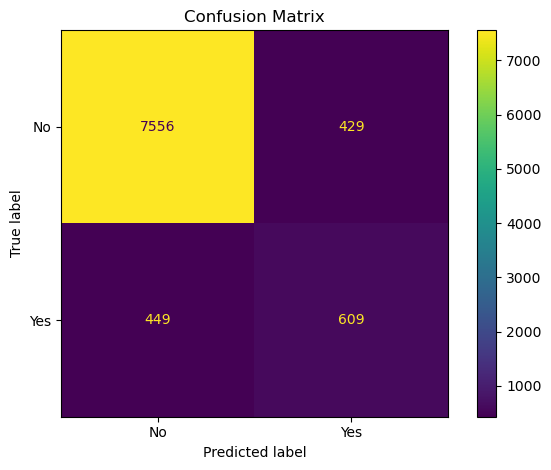

In [11]:
# Compute and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=300)
plt.show()

### ROC Curve
The ROC curve shows the trade-off between true positive rate and false positive rate.

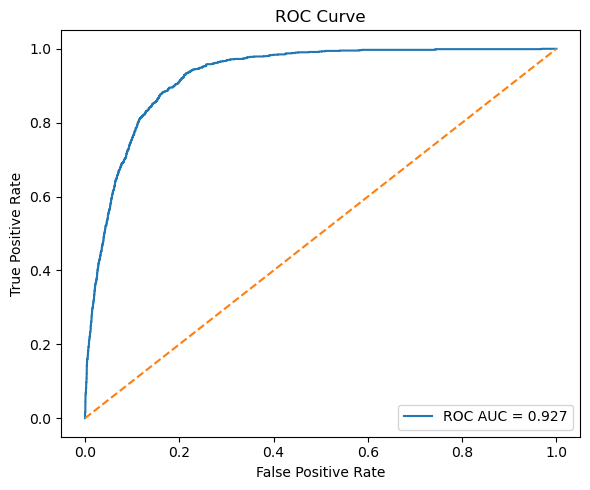

In [12]:
# Compute ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/roc_curve.png", dpi=300)
plt.show()

### Feature Importance
This helps identify which variables contribute most to the model’s predictions.

In [14]:
# Create feature importance table
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

# Display top 20 features
importance_df.head(20)

,feature,importance
3,duration,0.357378
0,age,0.054217
1,balance,0.053961
2,day,0.052119
7,balance_log,0.051321
45,poutcome_success,0.037155
32,contact_unknown,0.033735
5,pdays,0.031062
10,financial_pressure_score,0.030185
11,contact_intensity,0.019672


In [15]:
# Save feature importance table
importance_df.to_csv("../outputs/feature_importance.csv", index=False)

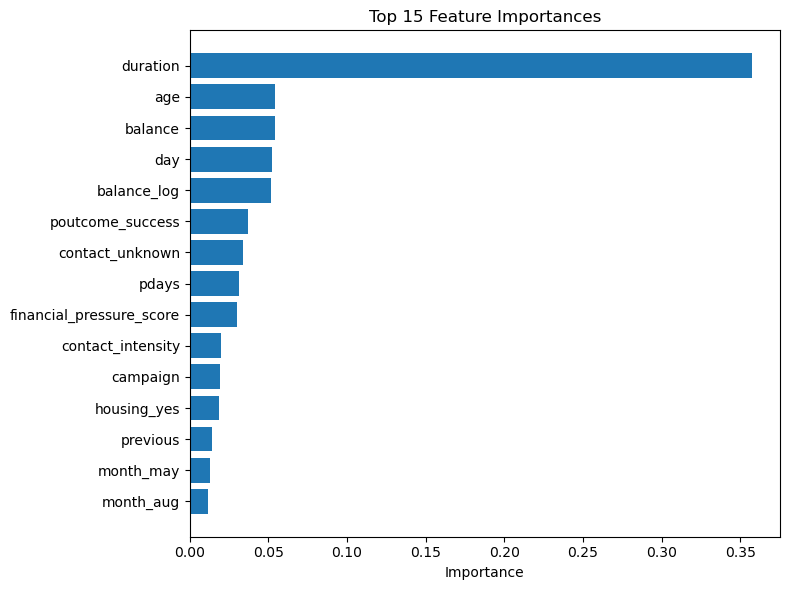

In [16]:
# Plot top 15 feature importances
top_features = importance_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/top_feature_importance.png", dpi=300)
plt.show()

### Decile Analysis
Decile analysis ranks customers by predicted conversion probability and helps evaluate targeting value.

In [18]:
# Create results dataframe
results = pd.DataFrame({
    "actual": y_test.values,
    "probability": y_prob
}).sort_values("probability", ascending=False).reset_index(drop=True)

# Assign deciles
results["decile"] = pd.qcut(results.index + 1, 10, labels=False) + 1

# Aggregate decile results
decile_table = results.groupby("decile").agg(
    customers=("actual", "size"),
    converters=("actual", "sum"),
    avg_probability=("probability", "mean")
).reset_index()

# Calculate conversion rate
decile_table["conversion_rate"] = decile_table["converters"] / decile_table["customers"]

# Save decile table
decile_table.to_csv("../outputs/decile_analysis.csv", index=False)

# Display decile table
decile_table

,decile,customers,converters,avg_probability,conversion_rate
0,1,905,552,0.674653,0.609945
1,2,904,309,0.429804,0.341814
2,3,904,127,0.250800,0.140487
3,4,904,41,0.134115,0.045354
4,5,905,16,0.073846,0.017680
5,6,904,8,0.045990,0.008850
6,7,904,2,0.030359,0.002212
7,8,904,2,0.020611,0.002212
8,9,904,0,0.012986,0.000000
9,10,905,1,0.005514,0.001105


## Conclusion
This project demonstrates a complete machine learning workflow for customer conversion prediction:
* ⁠data exploration
* ⁠feature engineering
* ⁠model building
* ⁠evaluation
* ⁠business interpretation

The model achieves strong predictive performance and provides useful insights for customer targeting and campaign optimization.